In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import *
from random import seed
from scipy import stats
import seaborn as sns
import pingouin as pg
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, Lasso
import statsmodels.api as sm
from statsmodels.stats.api import anova_lm
from statsmodels.formula.api import ols
from statsmodels.regression import linear_model
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
%matplotlib inline

seed(888)
pd.set_option('display.max_columns', None)

# 1 Load validation set

In [5]:
# load data from pickle and convert to dataframe
brain_test = pd.read_pickle("brain_test_validate.pkl")
main_test = pd.read_pickle("main_test_validate.pkl")
brain_train = pd.read_pickle("1_brain_train.pkl")
brain_test = pd.DataFrame(brain_test)
main_test = pd.DataFrame(main_test)
brain_train = pd.DataFrame(brain_train)

# 2 Preprocessing of validation set

## 2.2 BrainAge prediction for A2009 and All variables

### 2.2.1 A2009

In [6]:
X_train = brain_train.iloc[:,1657:2544:2]
Y_train = brain_train.iloc[:,-1]
X_test = brain_test.iloc[:,1657:2544:2]
Y_test = brain_test.iloc[:,-1]

# standardize x-data
X_train = stats.zscore(X_train)
X_test = stats.zscore(X_test)

# set of alphas to try (=penalization)
alpha_parameters = np.power(10,np.linspace(start=-3, stop=5, num=100))

Cross-validation

In [7]:
X_CV = X_train
Y_CV = Y_train

# randomly split data (only training no PA) into training and testing set
X_train_cv, X_test_cv, Y_train_cv, Y_test_cv = train_test_split(X_CV,Y_CV)

#define the model
model = RidgeCV(alphas = alpha_parameters)
#perform 10-fold cross validation
scores = cross_val_score(model, X_CV, Y_CV, cv=10, scoring='neg_mean_absolute_error')
#calculate the mean-absolute error
mae = -1 * scores.mean()
print("The MAE for cross-validation (Ridge):", mae)

# for correction
model.fit(X_train_cv,Y_train_cv)
y_pred_cv = model.predict(X_test_cv)

The MAE for cross-validation (Ridge): 4.206246715530011


The MAE for testing set using Ridge: 4.255363203323882
Index(['area_of_scalcarine_left_hemisphere_f27372_2_0',
       'volume_of_scalcarine_left_hemisphere_f27520_2_0',
       'volume_of_gfrontsup_left_hemisphere_f27492_2_0',
       'volume_of_gscingulant_right_hemisphere_f27704_2_0',
       'area_of_gfrontsup_left_hemisphere_f27344_2_0',
       'volume_of_sparietooccipital_right_hemisphere_f27763_2_0',
       'volume_of_scentral_left_hemisphere_f27521_2_0',
       'volume_of_latfispost_right_hemisphere_f27739_2_0',
       'area_of_scalcarine_right_hemisphere_f27594_2_0',
       'volume_of_scalcarine_right_hemisphere_f27742_2_0'],
      dtype='object')
[-1.58490537  1.58906398  1.60619697 -1.67635603 -1.749753    1.75977046
  1.86033162  2.16152389 -2.37541509  2.37603676]


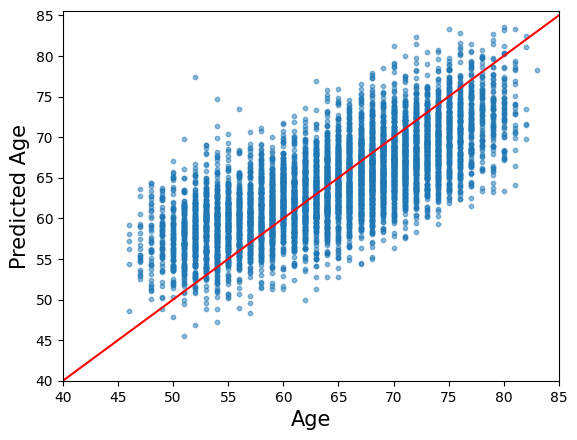

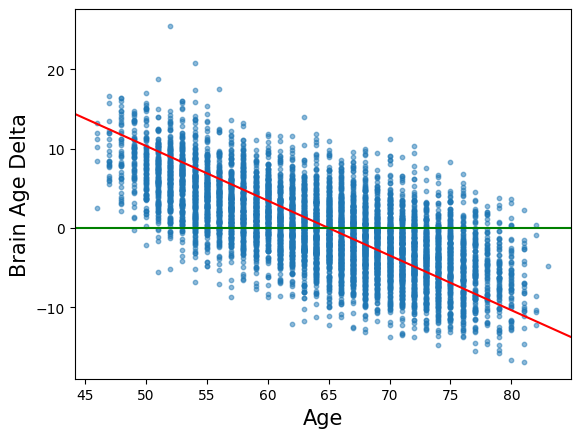

In [8]:
model_Lasso = LassoCV(alphas = alpha_parameters, max_iter=100000)
model_Ridge = RidgeCV(alphas = alpha_parameters)
model_SVR = SVR(kernel = 'rbf')

# train model 
model_Lasso.fit(X_train,Y_train)
model_Ridge.fit(X_train,Y_train)
model_SVR.fit(X_train,Y_train)

# get predicted values for test set
y_pred_Lasso = model_Lasso.predict(X_test)
y_pred_Ridge = model_Ridge.predict(X_test)
y_pred_SVR = model_SVR.predict(X_test)

# calculate brain age gap
brain_age_delta_Lasso = y_pred_Lasso-Y_test
brain_age_delta_Ridge = y_pred_Ridge-Y_test
brain_age_delta_SVR = y_pred_SVR-Y_test

# get mean absolute error (MAE)
print("The MAE for testing set using Lasso:", mean_absolute_error(Y_test,y_pred_Lasso))
print("The MAE for testing set using Ridge:", mean_absolute_error(Y_test,y_pred_Ridge))
print("The MAE for testing set using SVR:", mean_absolute_error(Y_test,y_pred_SVR))

# Spearman rank order correlations
print("The Spearman r for Ridge vs Lasso:", stats.spearmanr(brain_age_delta_Ridge, brain_age_delta_Lasso))
print("The Spearman r for Ridge vs SVR:", stats.spearmanr(brain_age_delta_Ridge, brain_age_delta_SVR))
print("The Spearman r for SVR vs Lasso:", stats.spearmanr(brain_age_delta_SVR, brain_age_delta_Lasso))

# top x coefficients and their names
coeff = np.asarray(model_Ridge.coef_)
coeffabs = np.asarray(abs(model_Ridge.coef_))
top_10_coefficients = np.argsort(coeffabs)[-20:]
print(X_train.iloc[:,top_10_coefficients].columns)
print(coeff[top_10_coefficients])

# plot figure with x: actual age Y: predicted age, and a line with slope 1 for reference
plt.figure()
plt.scatter(Y_test, y_pred_Ridge, alpha=0.5, s=10)
plt.axline((60,60), slope=1, color='r')
plt.xticks(range(40,90,5))
plt.yticks(range(40,90,5))
plt.ylabel('Predicted Age', fontsize = 15)
plt.xlabel('Age', fontsize = 15)
plt.show()

plt.figure()
plt.scatter(Y_test,brain_age_delta_Ridge, alpha=0.5, s=10)
# plt.axline((65,0), slope=-0.69, color="r")
plt.axline((60,0),slope=0, color = "g")
plt.ylabel("Brain Age Delta", fontsize = 15)
plt.xlabel("Age", fontsize = 15)
plt.show()

Coefficient and Intercept: 0.5363880561731595 29.98442047080509
The MAE for testing set corrected: 5.710721296840504


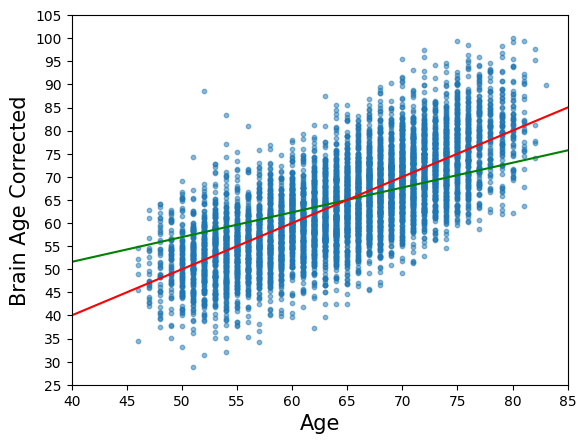

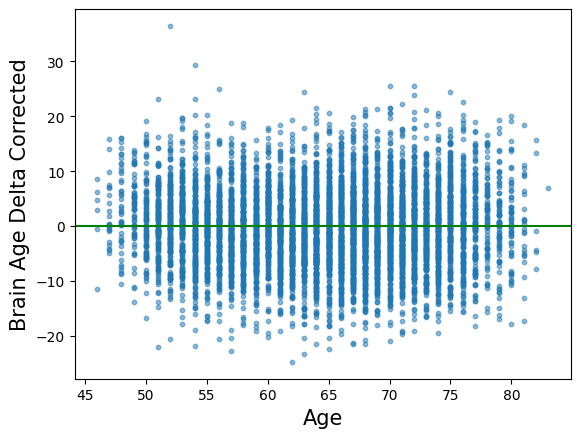

In [9]:
# reformat cross validation data for regression model
y_pred_cv = np.asarray(y_pred_cv)
y_pred_cv = np.reshape(y_pred_cv, (-1,1))
Y_test_cv = np.asarray(Y_test_cv)
Y_test_cv = np.reshape(Y_test_cv, (-1,1))

# now using correction from the R code that's online from Cole
reg = LinearRegression().fit(Y_test_cv, y_pred_cv)
coef = float(reg.coef_)
intercept = float(reg.intercept_)
print("Coefficient and Intercept:", coef, intercept)

# correction by cole
function = lambda t: (t-intercept)/coef
vfunc = np.vectorize(function)
corr_brainage_1 = vfunc(y_pred_Ridge)
corr_brainage_delta_1 = corr_brainage_1-Y_test

# plots corrected
plt.figure()
plt.scatter(Y_test, corr_brainage_1, alpha=0.5, s=10)
plt.axline((65,65), slope=coef, color="g")
plt.ylabel("Brain Age Corrected", fontsize = 15)
plt.axline((60,60), slope=1, color='r')
plt.xlabel("Age", fontsize = 15)
plt.xticks(range(40,90,5))
plt.yticks(range(25,110,5))
plt.show()

plt.figure()
plt.scatter(Y_test, corr_brainage_delta_1, alpha=0.5, s=10)
plt.axline((60,0),slope=0, color = "g")
plt.ylabel("Brain Age Delta Corrected", fontsize = 15)
plt.xlabel("Age", fontsize = 15)
plt.show()

### 2.2.3 Add BrainAge Deltas to Dataframe

In [10]:
main_test["BA"] = corr_brainage_delta_1

## 2.4 Recoding

In [11]:
# 1 = Cheadle;  2 = Reading;  3 = Newcastle;  4 = Bristol
main_test['IS'] = main_test['IS'].map({'11025': 1, '11026': 2,'11027': 3, '11028': 4})
main_test["Gender"] = main_test["Gender"].map({"Female":0, "Male":1})
main_test["Gender"] = main_test["Gender"].astype("int")
main_test["JPA"] = main_test["JPA"].map({"Never/rarely":0, "Sometimes":1, "Usually":2,"Always":3})

main_test = pd.DataFrame(main_test)


# 3 Basic distributions of validation set

## 3.1 Data and Descriptives

In [12]:
main_test.head()

,ID,Age,Gender,TPA,VPA,MPA,MVPA,LPA,BMI,SRLPA,SRMPA,SRVPA,FI,HG,IS,SES,HR,JPA,DBP,SBP,BA
3837,1446068,58.0,0,3277.3248,100.2240,1002.240,1202.6880,2174.8608,31.6,825.0,200.0,640.0,6.0,28.0,3,-4.69745,68.0,0.0,84.0,147.0,4.086438
20495,3398445,72.0,0,1814.4000,30.2400,463.680,524.1600,1320.4800,31.4,1155.0,840.0,1120.0,5.0,34.0,2,2.12396,52.0,0.0,81.0,129.0,-7.056466
27568,4234134,61.0,0,2542.4496,9.8928,346.248,366.0336,2186.3088,19.0,99.0,480.0,1200.0,7.0,28.0,1,-2.17172,63.0,0.0,76.0,111.0,-3.089301
21141,3469881,77.0,1,2076.4800,10.0800,463.680,483.8400,1602.7200,24.3,693.0,360.0,560.0,5.0,46.0,1,-4.29012,58.0,NaN,79.0,161.0,4.419493
23548,3761931,64.0,0,2691.3600,20.1600,735.840,776.1600,1935.3600,22.1,825.0,600.0,720.0,8.0,32.0,1,-4.06643,82.0,NaN,71.0,151.0,-12.845676


In [13]:
female = main_test[main_test["Gender"] == 0]
male = main_test[main_test["Gender"]== 1]

print(female.shape)
print(male.shape)

print("Age")
mean = female["Age"].mean()
print("Female", mean)
std = female["Age"].std()
print("Female",std)
mean = male["Age"].mean()
print("Male",mean)
std = male["Age"].std()
print("Male",std)

print("LPA")
mean = female["LPA"].mean()
print("Female", mean)
std = female["LPA"].std()
print("Female",std)
mean = male["LPA"].mean()
print("Male",mean)
std = male["LPA"].std()
print("Male",std)

print("MPA")
mean = female["MPA"].mean()
print("Female", mean)
std = female["MPA"].std()
print("Female",std)
mean = male["MPA"].mean()
print("Male",mean)
std = male["MPA"].std()
print("Male",std)

print("VPA")
mean = female["VPA"].mean()
print("Female", mean)
std = female["VPA"].std()
print("Female",std)
mean = male["VPA"].mean()
print("Male",mean)
std = male["VPA"].std()
print("Male",std)

print("BMI")
mean = female["BMI"].mean()
print("Female", mean)
std = female["BMI"].std()
print("Female",std)
mean = male["BMI"].mean()
print("Male",mean)
std = male["BMI"].std()
print("Male",std)

# add all variables here

(4125, 21)
(3366, 21)
Age
Female 63.62715151515152
Female 7.580421701285927
Male 65.52703505644682
Male 7.943841518514945
LPA
Female 2067.809091490909
Female 411.6263917130586
Male 1902.9337540106949
Male 406.79782405517733
MPA
Female 499.9992401454547
Female 228.80082449827026
Male 473.8800171122996
Male 224.55957057748347
VPA
Female 31.631720727272754
Female 41.768286250377976
Male 37.477022459893085
Male 46.82436227781068
BMI
Female 25.91621156211562
Female 4.497081885703942
Male 26.93078078078078
Male 3.8746441408695684


## 3.2 Age and BrainAge

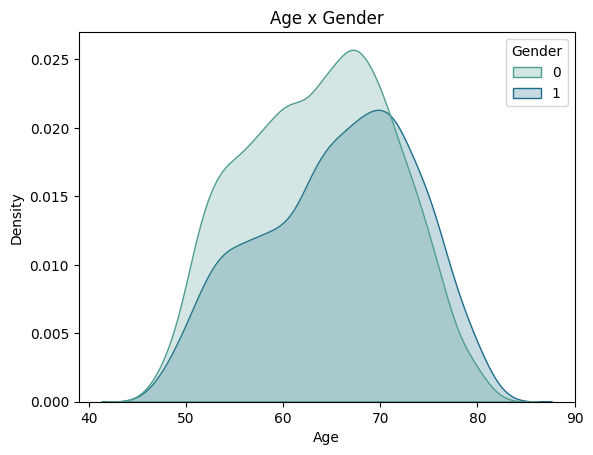

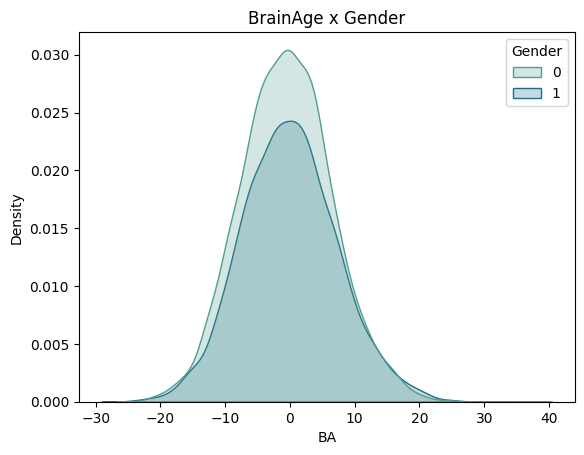

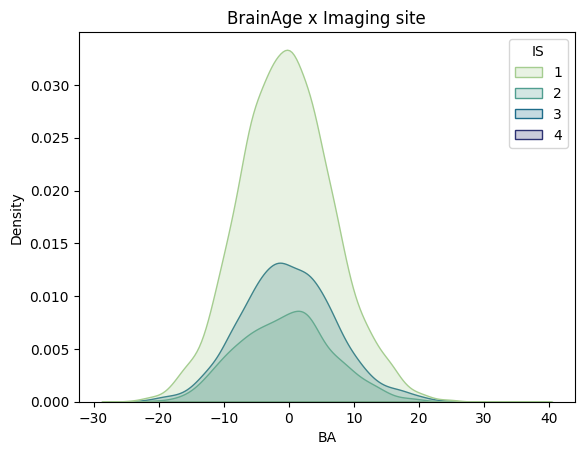

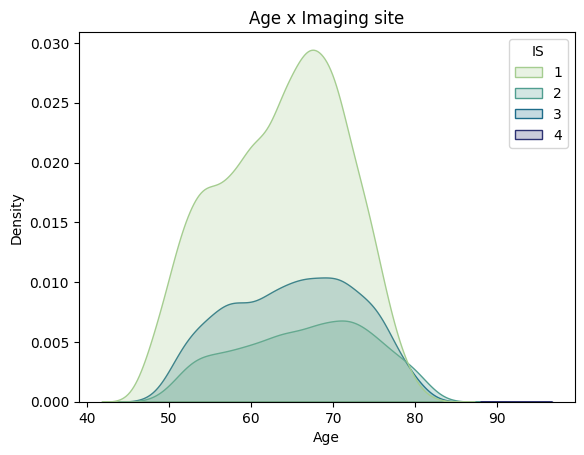

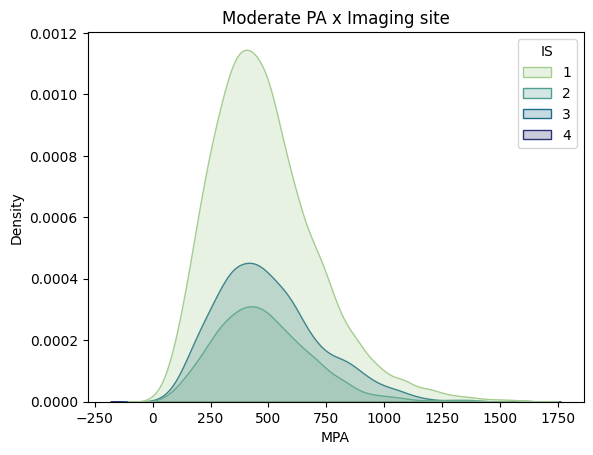

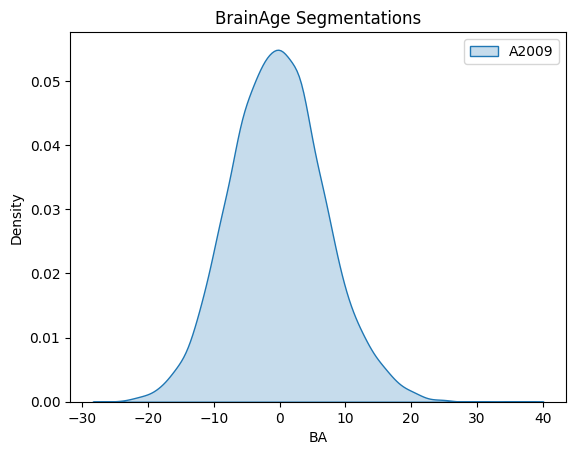

In [14]:
plt.figure()
sns.kdeplot(data = main_test, x= 'Age', hue = 'Gender', fill=True, palette = "crest")
plt.title("Age x Gender")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'BA', hue = 'Gender', fill=True, palette = "crest")
plt.title("BrainAge x Gender")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'BA', hue = 'IS', fill=True, palette = "crest")
plt.title("BrainAge x Imaging site")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'Age', hue = 'IS', fill=True, palette = "crest")
plt.title("Age x Imaging site")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'MPA', hue = 'IS', fill=True, palette = "crest")
plt.title("Moderate PA x Imaging site")
plt.show()


plt.figure()
sns.kdeplot(data = main_test, x= 'BA', fill=True, label="A2009")
plt.title("BrainAge Segmentations")
plt.legend()
plt.show()

## 3.3 Physical activity

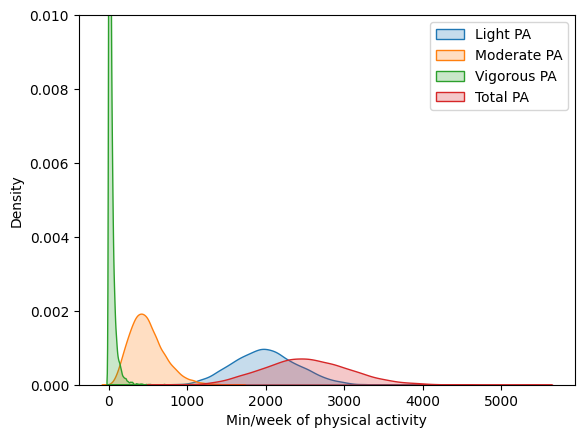

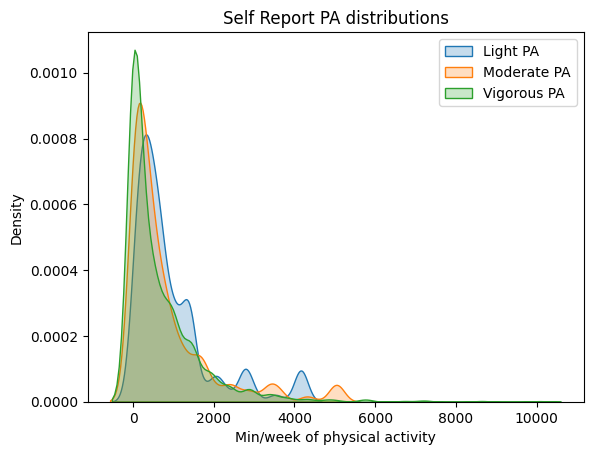

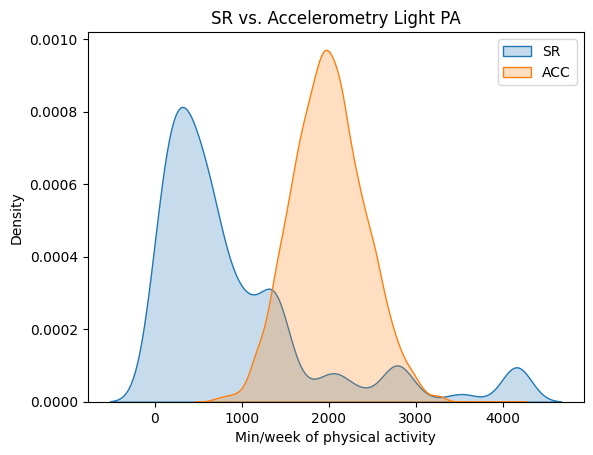

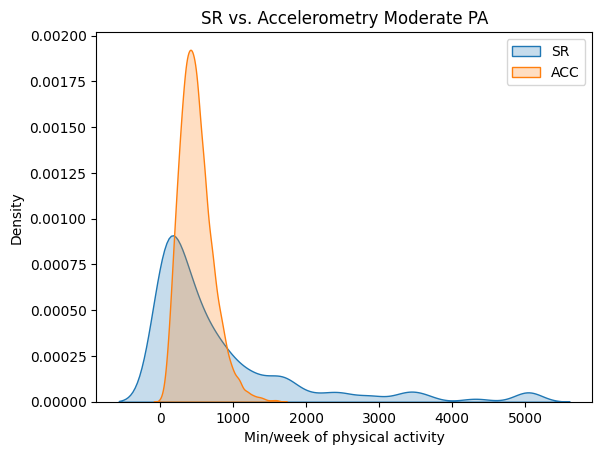

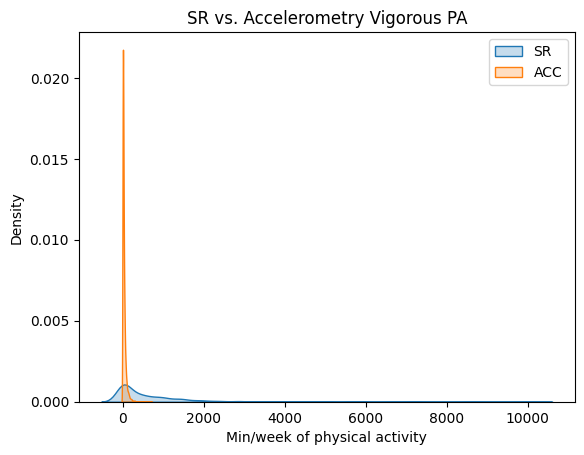

In [15]:
plt.figure()
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA")
sns.kdeplot(data = main_test, x= 'TPA', fill=True, label = "Total PA")
plt.xlabel("Min/week of physical activity")
plt.legend()
plt.ylim(0,0.01)
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "Light PA")
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "Moderate PA")
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "Vigorous PA")
plt.xlabel("Min/week of physical activity")
plt.title("Self Report PA distributions")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR")
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "ACC")
plt.xlabel("Min/week of physical activity")
plt.title("SR vs. Accelerometry Light PA")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "ACC")
plt.xlabel("Min/week of physical activity")
plt.title("SR vs. Accelerometry Moderate PA")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "ACC")
plt.xlabel("Min/week of physical activity")
plt.title("SR vs. Accelerometry Vigorous PA")
plt.legend()
plt.show()

## 3.4 Health and Fitness

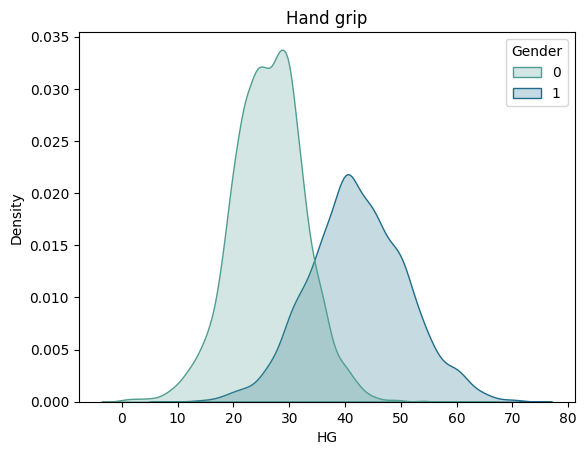

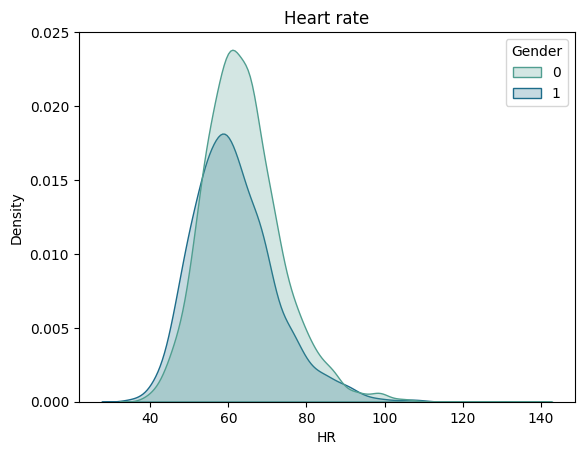

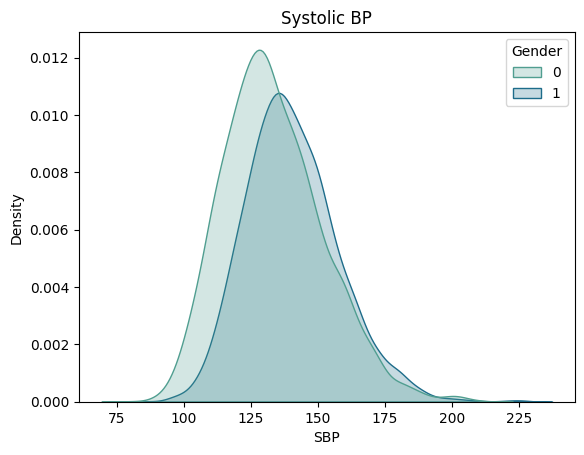

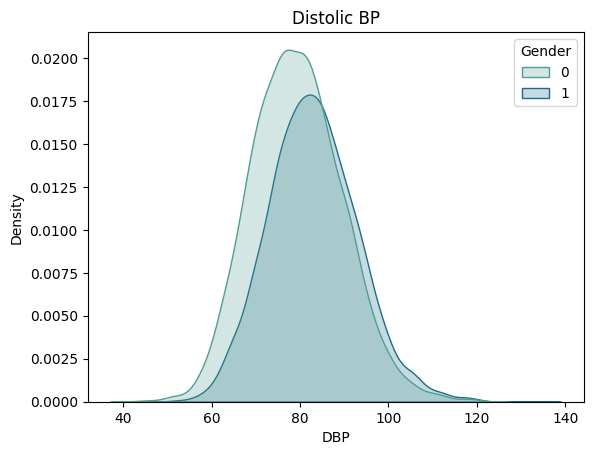

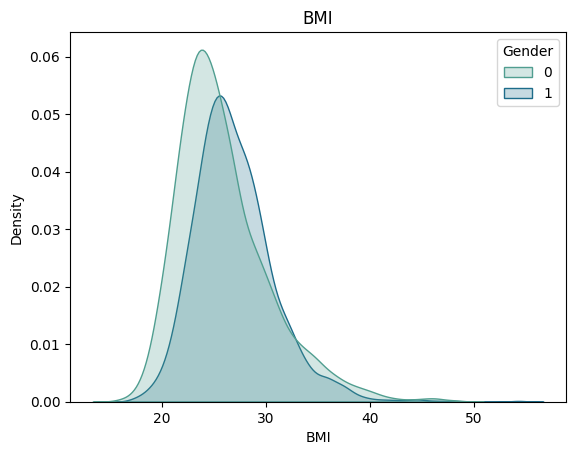

In [16]:
plt.figure()
sns.kdeplot(data = main_test, x= 'HG', hue = 'Gender', fill=True, palette = "crest")
plt.title("Hand grip")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'HR', hue = 'Gender', fill=True, palette = "crest")
plt.title("Heart rate")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Systolic BP")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'DBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Distolic BP")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'BMI', hue = 'Gender', fill=True, palette = "crest")
plt.title("BMI")
plt.show()

In [17]:
main_test = stats.zscore(main_test,nan_policy='omit')

# 4 Simple Correlation Heatmap

Text(0.5, 1.0, 'Correlations All')

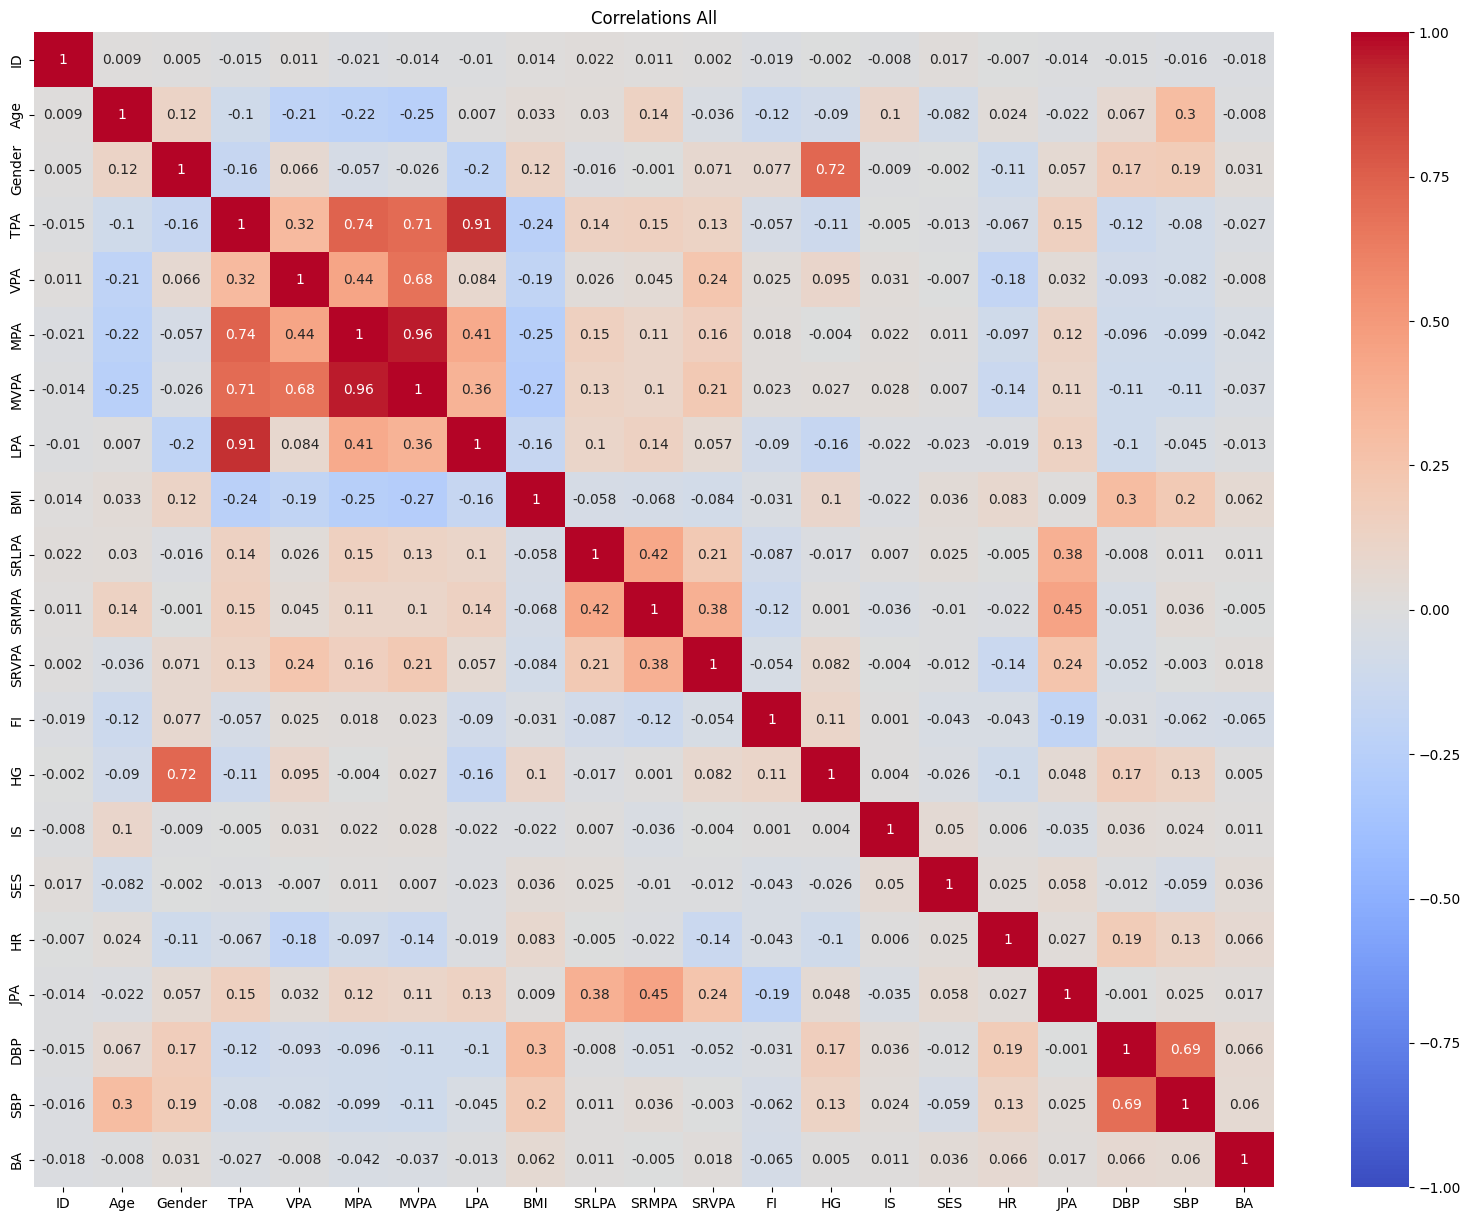

In [18]:
corr = main_test.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(20,15)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.title("Correlations All")

# 5 Partial Correlations with Covariates

In [19]:
cov_correlation = pg.partial_corr(data=main_test, x='SRLPA', y='BA', covar=["Gender", "IS", "Age"])
print("SR Light PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='SRMPA', y='BA', covar=["Gender", "IS", "Age"])
print("SR Moderate PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='SRVPA', y='BA', covar=["Gender", "IS", "Age"])
print("SR Vigorous PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='TPA', y='BA', covar=["Gender", "IS", "Age"])
print("Total PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='LPA', y='BA', covar=["Gender", "IS", "Age"])
print("Light PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='MPA', y='BA', covar=["Gender", "IS", "Age"])
print("Moderate PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='VPA', y='BA', covar=["Gender", "IS", "Age"])
print("Vigorous PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='MVPA', y='BA', covar=["Gender", "IS", "Age"])
print("Moderate+Vigorous PA")
print(cov_correlation)

SR Light PA
            n         r          CI95%     p-val
pearson  6428  0.012069  [-0.01, 0.04]  0.333436
SR Moderate PA
            n        r          CI95%     p-val
pearson  6428 -0.00123  [-0.03, 0.02]  0.921466
SR Vigorous PA
            n         r          CI95%     p-val
pearson  6428  0.015496  [-0.01, 0.04]  0.214258
Total PA
            n         r          CI95%     p-val
pearson  7491 -0.023492  [-0.05, -0.0]  0.042078
Light PA
            n         r          CI95%     p-val
pearson  7491 -0.006403  [-0.03, 0.02]  0.579564
Moderate PA
            n         r           CI95%     p-val
pearson  7491 -0.044241  [-0.07, -0.02]  0.000128
Vigorous PA
            n         r          CI95%    p-val
pearson  7491 -0.013992  [-0.04, 0.01]  0.22603
Moderate+Vigorous PA
            n         r           CI95%     p-val
pearson  7491 -0.040926  [-0.06, -0.02]  0.000397


# 6 Models with OLS

## 6.1 Covariates

In [20]:
cov_model = ols('BA ~ Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(cov_model.summary())

#calculate effect size
results = cov_model
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     5.179
Date:                Fri, 13 Jan 2023   Prob (F-statistic):           2.52e-05
Time:                        16:50:32   Log-Likelihood:                -10614.
No. Observations:                7491   AIC:                         2.124e+04
Df Residuals:                    7484   BIC:                         2.129e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0070      0.012     -0.603      0.5

## 6.2 Accelerometer PA

In [21]:
pa_model = ols('BA ~ LPA + MPA + VPA + Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(pa_model.summary())

#calculate effect size
results = pa_model
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     5.249
Date:                Fri, 13 Jan 2023   Prob (F-statistic):           3.74e-07
Time:                        16:50:32   Log-Likelihood:                -10606.
No. Observations:                7491   AIC:                         2.123e+04
Df Residuals:                    7481   BIC:                         2.130e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0070      0.012     -0.599      0.5

## 6.3 Self-report PA

In [22]:
sr_model = ols('BA ~ SRLPA + SRMPA + SRVPA +Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(sr_model.summary())

#calculate effect size
results = sr_model
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     3.865
Date:                Fri, 13 Jan 2023   Prob (F-statistic):           6.69e-05
Time:                        16:50:32   Log-Likelihood:                -9085.2
No. Observations:                6428   AIC:                         1.819e+04
Df Residuals:                    6418   BIC:                         1.826e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0077      0.013     -0.608      0.5

## 6.4 SR + Job PA + FI

In [23]:
sr_ex_model = ols('BA ~ SRLPA + SRMPA + SRVPA + FI + JPA + Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(sr_ex_model.summary())

#calculate effect size
results = sr_ex_model
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     4.062
Date:                Fri, 13 Jan 2023   Prob (F-statistic):           6.11e-06
Time:                        16:50:33   Log-Likelihood:                -4341.5
No. Observations:                3108   AIC:                             8707.
Df Residuals:                    3096   BIC:                             8779.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0636      0.020     -3.253      0.0

## 6.5 Accelerometer + Self-report PA

In [24]:
sr_pa_model = ols('BA ~ SRLPA + SRMPA + SRVPA +LPA + MPA + VPA+ Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(sr_pa_model.summary())

#calculate effect size
results = sr_pa_model
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     4.387
Date:                Fri, 13 Jan 2023   Prob (F-statistic):           5.11e-07
Time:                        16:50:33   Log-Likelihood:                -9076.3
No. Observations:                6428   AIC:                         1.818e+04
Df Residuals:                    6415   BIC:                         1.827e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0068      0.013     -0.537      0.5

## 6.6 PA + Fitness

In [25]:
pa_fitness = ols('BA ~ HG + LPA + MPA + VPA + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(pa_fitness.summary())

#calculate effect size
results = pa_fitness
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     5.403
Date:                Fri, 13 Jan 2023   Prob (F-statistic):           5.14e-08
Time:                        16:50:33   Log-Likelihood:                -10572.
No. Observations:                7466   AIC:                         2.117e+04
Df Residuals:                    7455   BIC:                         2.124e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0068      0.012     -0.582      0.5

## 6.7 Fitness

In [26]:
fitness = ols('BA ~ HG + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(fitness.summary())

#calculate effect size
results = fitness
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.468
Date:                Fri, 13 Jan 2023   Prob (F-statistic):           2.79e-06
Time:                        16:50:33   Log-Likelihood:                -10580.
No. Observations:                7466   AIC:                         2.118e+04
Df Residuals:                    7458   BIC:                         2.123e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0069      0.012     -0.586      0.5

## 6.8 Health

In [27]:
health = ols('BA ~ SBP + HR + DBP + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(health.summary())

#calculate effect size
results = health
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     9.604
Date:                Fri, 13 Jan 2023   Prob (F-statistic):           1.10e-14
Time:                        16:50:33   Log-Likelihood:                -8285.5
No. Observations:                5881   AIC:                         1.659e+04
Df Residuals:                    5871   BIC:                         1.666e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0142      0.013     -1.079      0.2

## 6.9 Health and Fitness

In [28]:
he_fi = ols('BA ~ HG + SBP + HR + DBP + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(he_fi.summary())

#calculate effect size
results = he_fi
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     9.485
Date:                Fri, 13 Jan 2023   Prob (F-statistic):           7.99e-16
Time:                        16:50:34   Log-Likelihood:                -8257.1
No. Observations:                5861   AIC:                         1.654e+04
Df Residuals:                    5850   BIC:                         1.661e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0139      0.013     -1.055      0.2

## 6.10 Fluid intelligence

In [29]:
fi = ols('BA ~ FI + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(fi.summary())

#calculate effect size
results = fi
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     7.686
Date:                Fri, 13 Jan 2023   Prob (F-statistic):           2.88e-09
Time:                        16:50:34   Log-Likelihood:                -7558.4
No. Observations:                5357   AIC:                         1.513e+04
Df Residuals:                    5349   BIC:                         1.519e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0197      0.014     -1.430      0.1

## 6.11 Fitness models

In [30]:
fit = ols('HG ~ LPA + MPA + VPA + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(fit.summary())

#calculate effect size
results = fit
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     HG   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     1048.
Date:                Fri, 13 Jan 2023   Prob (F-statistic):               0.00
Time:                        16:50:34   Log-Likelihood:                -7541.3
No. Observations:                7466   AIC:                         1.510e+04
Df Residuals:                    7456   BIC:                         1.517e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0012      0.008      0.159      0.8

In [31]:
fit2 = ols('HG ~ LPA + MPA + VPA + SRLPA + SRMPA + SRVPA + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(fit2.summary())

#calculate effect size
results = fit2
coefficients = results.params
t_stats = results.tvalues
effect_size = coefficients / t_stats
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     HG   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     667.2
Date:                Fri, 13 Jan 2023   Prob (F-statistic):               0.00
Time:                        16:50:34   Log-Likelihood:                -6474.9
No. Observations:                6407   AIC:                         1.298e+04
Df Residuals:                    6394   BIC:                         1.306e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0009      0.008     -0.107      0.9

# 7 Model comparisons

## 7.1 Cov x PA

In [32]:
model_comparison = anova_lm(cov_model, pa_model)
print(model_comparison)

   df_resid          ssr  df_diff    ss_diff         F    Pr(>F)
0    7484.0  7460.028158      0.0        NaN       NaN       NaN
1    7481.0  7443.995420      3.0  16.032738  5.370813  0.001084


In [33]:
model_comparison = anova_lm(cov_model, sr_model)
print(model_comparison)

   df_resid          ssr  df_diff      ss_diff         F    Pr(>F)
0    7484.0  7460.028158      0.0          NaN       NaN       NaN
1    6418.0  6356.968740   1066.0  1103.059419  1.044699  0.170842


## 7.2 Cov x PA x SR

In [34]:
model_comparison = anova_lm(sr_model, sr_pa_model)
print(model_comparison)

   df_resid          ssr  df_diff    ss_diff         F    Pr(>F)
0    6418.0  6356.968740      0.0        NaN       NaN       NaN
1    6415.0  6339.402044      3.0  17.566696  5.925393  0.000495


In [35]:
model_comparison = anova_lm(pa_model, sr_pa_model)
print(model_comparison)

   df_resid          ssr  df_diff      ss_diff         F   Pr(>F)
0    7481.0  7443.995420      0.0          NaN       NaN      NaN
1    6415.0  6339.402044   1066.0  1104.593377  1.048561  0.15138


## 7.3 SR x Job + FI

In [36]:
model_comparison = anova_lm(sr_model, sr_ex_model)
print(model_comparison)

   df_resid          ssr  df_diff      ss_diff         F    Pr(>F)
0    6418.0  6356.968740      0.0          NaN       NaN       NaN
1    3096.0  2973.794683   3322.0  3383.174057  1.060266  0.048937


## 7.4 Fitness models

In [37]:
model_comparison = anova_lm(fit, fit2)
print(model_comparison)

   df_resid          ssr  df_diff     ss_diff         F    Pr(>F)
0    7456.0  3295.841434      0.0         NaN       NaN       NaN
1    6394.0  2831.188549   1062.0  464.652885  0.988116  0.596212


# 8 Mediation analysis

## 8.1 PA x Health / Fitness

### 8.1.1 BMI

In [38]:
#regression of x on m
model1 = ols('BMI ~ MPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ BMI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ MPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['MPA'] * model2.params['BMI']
#calculate the total effect
total_effect = model3.params['MPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -0.01568072581623246
Direct effect: -0.02602006106096409
Total effect: -0.04170078687719655


### 8.1.2 DBP

In [39]:
#regression of x on m
model1 = ols('DBP ~ MPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ DBP',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ MPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['MPA'] * model2.params['DBP']
#calculate the total effect
total_effect = model3.params['MPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -0.006290794891844415
Direct effect: -0.035409991985352135
Total effect: -0.04170078687719655


### 8.1.3 Heart rate

In [40]:
#regression of x on m
model1 = ols('HR ~ MPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HR',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ MPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['MPA'] * model2.params['HR']
#calculate the total effect
total_effect = model3.params['MPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -0.00642280899080565
Direct effect: -0.0352779778863909
Total effect: -0.04170078687719655


### 8.1.4 Hand grip

In [41]:
#regression of x on m
model1 = ols('HG ~ MPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HG',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ MPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['MPA'] * model2.params['HG']
#calculate the total effect
total_effect = model3.params['MPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: -1.8532067887943007e-05
Direct effect: -0.04168225480930861
Total effect: -0.04170078687719655


## 8.2 SR PA x Job PA / Fluid intelligence

In [42]:
#regression of x on m
model1 = ols('FI ~ SRMPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ FI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ SRMPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['SRMPA'] * model2.params['FI']
#calculate the total effect
total_effect = model3.params['SRMPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: 0.00831302225717287
Direct effect: -0.013327935251611423
Total effect: -0.005014912994438554


In [43]:
#regression of x on m
model1 = ols('FI ~ SRMPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ FI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ SRMPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['SRMPA'] * model2.params['FI']
#calculate the total effect
total_effect = model3.params['SRMPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: 0.00831302225717287
Direct effect: -0.013327935251611423
Total effect: -0.005014912994438554


In [44]:
#regression of x on m
model1 = ols('FI ~ JPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ FI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ JPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = model1.params['JPA'] * model2.params['FI']
#calculate the total effect
total_effect = model3.params['JPA']
#calculate the direct effect
direct_effect = total_effect - indirect_effect
#print the results
print('Indirect effect: '+str(indirect_effect))
print('Direct effect: '+str(direct_effect))
print('Total effect: '+str(total_effect))

Indirect effect: 0.013033057831658066
Direct effect: 0.004124800993474575
Total effect: 0.01715785882513264


# 9 LASSO Regression

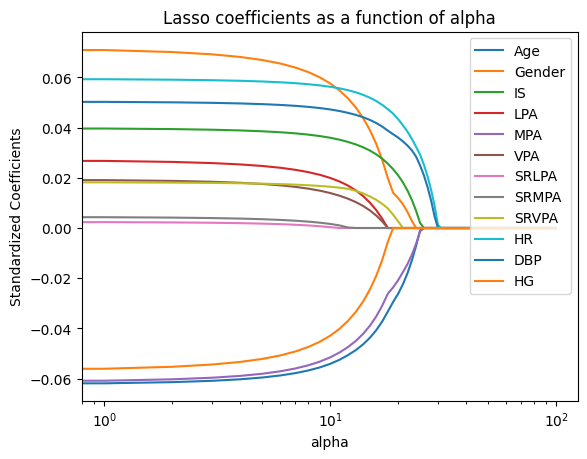

In [45]:
df = main_test[["Age", "Gender", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Gender", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG"]]
Y = df["BA"]
columns = ["Age", "Gender", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)

plt.plot(coefs)
plt.xticks(alphas)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('Standardized Coefficients')
plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")

# 10 Pickle for comparison to exploration set

In [46]:
main_test.to_pickle("6_main_test.pkl")